# Issue #5 — Glowy Sheen, Repurposed

**Pillar:** 5 (trend forecast, with receipts)

**Story:** "Skin tint" isn't disappearing, it's being renamed. The market is adapting to the results it promises, skin that looks
like skin, with products relaunching under a new label every time the last one fades: tinted moisturizer,
BB cream, serum foundation, "skin-like finish." The finish survives. The name never does.

**Scope:**
- Data: first-party Google Trends pull via `trendspy` for "skin tint," "tinted moisturizer," "BB
  cream," and "skin-like finish," cross-referenced against a single-sourced Market Defense/BeautyMatter
  quote.
- Anchor: the crash, not the climb. Search interest for "skin tint" fell -75% in three months
  (60 → 15), after peaking at 100 on April 12, 2026, the final day of Coachella Weekend 1. All three
  active terms peaked on that exact date, direct evidence that the fragmentation is one shared
  phenomenon, not three unrelated trends
- Chart 5.1: Trend data  (notebook: 5.1-trend-data)
  The hero line chart with all four search terms plotted together
- Chart 5.2: Combined cost chart (notebook-5.2-cost-chart)  
  Products analysed, annotated with the British Beauty Council's 2%-cosmetics-overproduction-waste stat as a callout, carrying both the redundant-purchase and waste angles in one visual:   
    - Budget tier: Rimmel, The Ordinary, Maybelline  
    - High-end tier: MAKE UP FOR EVER, Hourglass  

## 1. Setup

In [2]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
from pathlib import Path
from datetime import datetime

# pip install trendspy --break-system-packages
from trendspy import Trends

# set up export folders
ISSUE = "issue-05-glowy-sheen-repurposed"
DATA_OUT = Path(f"../../data/processed/{ISSUE}")
CHART_OUT = Path(f"../../content/posts/{ISSUE}/exports")
DATA_OUT.mkdir(parents=True, exist_ok=True)
CHART_OUT.mkdir(parents=True, exist_ok=True)

## 2. Load brand data

In [3]:
# load brand palette
with open("../../brand/palette.json") as f:
    palette_data = json.load(f)

palette = {c["name"]: c["hex"] for c in palette_data["palette"]}

COCOA = palette["Cocoa"]
DUSTY = palette["Dusty"]
PEACH = palette["Peach"]
CREAM = palette["Cream"]
SAGE  = palette["Sage"]

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.facecolor"] = COCOA
plt.rcParams["figure.facecolor"] = COCOA
plt.rcParams["text.color"] = CREAM
plt.rcParams["axes.labelcolor"] = CREAM
plt.rcParams["xtick.color"] = CREAM
plt.rcParams["ytick.color"] = CREAM

## 3. Pull Google Trends data

In [4]:
tr = Trends()

TERM_SKIN_TINT = "skin tint"
TERM_TINTED_MOISTURIZER = "tinted moisturizer"
TERM_BB_CREAM = "BB cream"
TERM_SKIN_LIKE_FINISH = "skin-like finish"

trends_df = tr.interest_over_time(
    [TERM_SKIN_TINT, TERM_TINTED_MOISTURIZER, TERM_BB_CREAM, TERM_SKIN_LIKE_FINISH],
    timeframe="2023-08-01 2026-08-21",
    geo="US"
)

trends_df.to_csv(DATA_OUT / "google_trends_raw.csv")
trends_df.tail()

,skin tint,tinted moisturizer,BB cream,skin-like finish,isPartial
time [UTC],,,,,
2026-07-19,16,8,7,0,False
2026-07-26,16,9,8,0,False
2026-08-02,16,8,7,0,False
2026-08-09,15,8,7,0,False
2026-08-16,14,8,7,0,True


### 3.1 Sanity check and clean

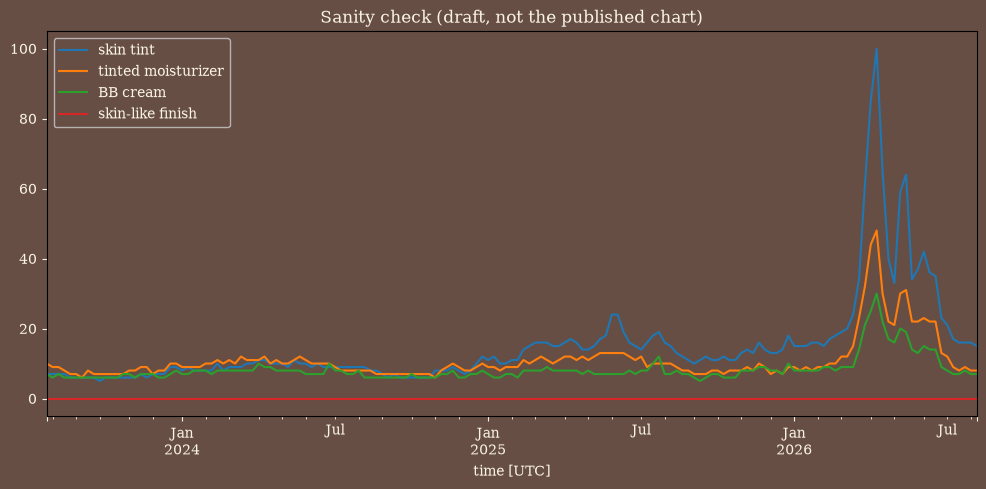

In [5]:
if "isPartial" in trends_df.columns:
    trends_df = trends_df[trends_df["isPartial"] == False].drop(columns=["isPartial"])

fig, ax = plt.subplots(figsize=(12, 5))
for term, color in zip(
    [TERM_SKIN_TINT, TERM_TINTED_MOISTURIZER, TERM_BB_CREAM, TERM_SKIN_LIKE_FINISH],
    [COCOA, DUSTY, PEACH, SAGE]
):
    if term in trends_df.columns:
        trends_df[term].plot(ax=ax, label=term)
ax.legend()
ax.set_title("Sanity check (draft, not the published chart)")
plt.show()

### 3.2 Compute the interest-increase stat

In [6]:
# Find the peak for "skin tint"
peak_date = trends_df[TERM_SKIN_TINT].idxmax()
peak_value = trends_df[TERM_SKIN_TINT].max()
print(f"Peak search interest for '{TERM_SKIN_TINT}': {peak_value} on {peak_date.date()}")

weeks_since_peak = (trends_df.index.max() - peak_date).days // 7
print(f"That's {weeks_since_peak} weeks before the most recent data point ({trends_df.index.max().date()})")

for term in [TERM_TINTED_MOISTURIZER, TERM_BB_CREAM]:
    if term in trends_df.columns:
        t_peak_date = trends_df[term].idxmax()
        t_peak_value = trends_df[term].max()
        print(f"Peak search interest for '{term}': {t_peak_value} on {t_peak_date.date()}")

Peak search interest for 'skin tint': 100 on 2026-04-12
That's 17 weeks before the most recent data point (2026-08-09)
Peak search interest for 'tinted moisturizer': 48 on 2026-04-12
Peak search interest for 'BB cream': 30 on 2026-04-12


In [7]:
# Compute % change in "skin tint" interest over the trailing 3 months
last_date = trends_df.index.max()
three_months_ago = last_date - pd.DateOffset(months=3)

recent = trends_df.loc[trends_df.index >= three_months_ago, TERM_SKIN_TINT]

start_val = recent.iloc[0]
end_val = recent.iloc[-1]

if start_val > 0:
    pct_change = ((end_val - start_val) / start_val) * 100
    print(f"'{TERM_SKIN_TINT}' search interest: {start_val} -> {end_val} "
          f"({pct_change:+.1f}% over trailing 3 months)")
else:
    print(f"Start value is 0 ({start_val}), percent change is undefined — "
          f"consider reporting the raw index shift instead.")

full_start = trends_df[TERM_SKIN_TINT].iloc[0]
full_end = trends_df[TERM_SKIN_TINT].iloc[-1]
print(f"Full window ({trends_df.index.min().date()} to {trends_df.index.max().date()}): "
      f"{full_start} -> {full_end}")

'skin tint' search interest: 59 -> 15 (-74.6% over trailing 3 months)
Full window (2023-07-30 to 2026-08-09): 7 -> 15


## 4. Compute the hero chart

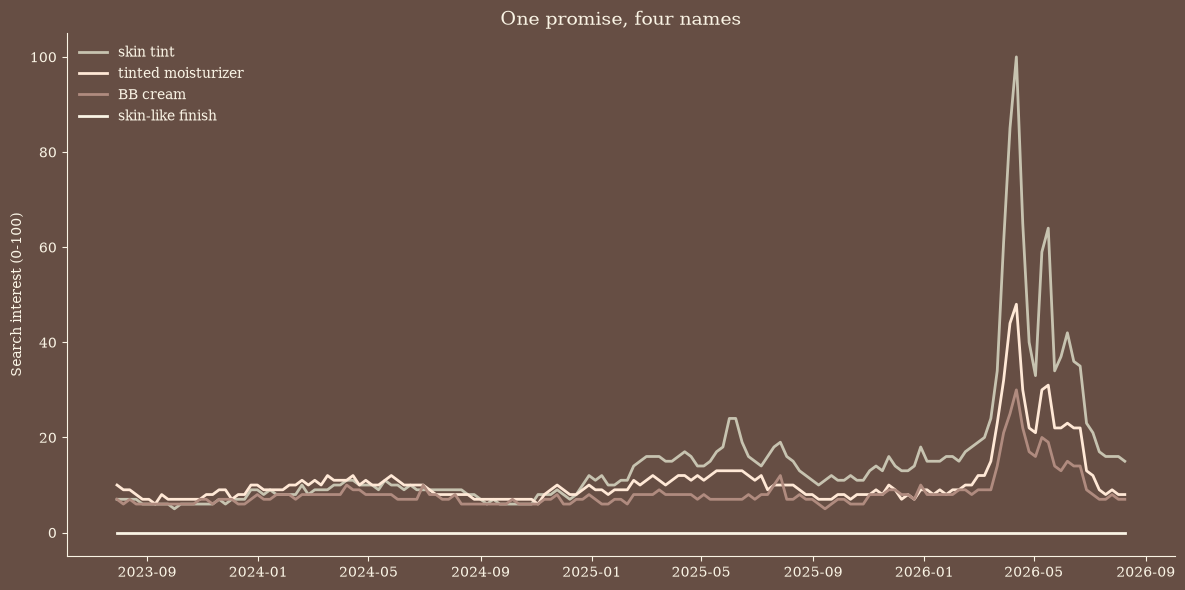

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

term_colors = {
    TERM_SKIN_TINT: SAGE,
    TERM_TINTED_MOISTURIZER: PEACH,
    TERM_BB_CREAM: DUSTY,
    TERM_SKIN_LIKE_FINISH: CREAM,
}

for term, color in term_colors.items():
    if term in trends_df.columns:
        ax.plot(trends_df.index, trends_df[term], label=term, color=color, linewidth=2)

ax.set_title("One promise, four names", color=CREAM, fontsize=14)
ax.set_ylabel("Search interest (0-100)")
ax.legend(loc="upper left", frameon=False, labelcolor=CREAM)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(CREAM)
ax.tick_params(axis="both", colors=CREAM)

plt.tight_layout()
plt.show()

## 5. Save outputs

In [13]:
out_png = CHART_OUT / "trend_chart.png"
fig.savefig(out_png, facecolor=fig.get_facecolor(), bbox_inches="tight")
print(f"Chart saved to: {out_png}")

# trends_df itself was already saved to google_trends_raw.csv in Section 3

Chart saved to: ..\..\content\posts\issue-05-glowy-sheen-repurposed\exports\trend_chart.png
